# Relax Inc

Defining an "adopted user" as a user who has logged into the product on three separate days in at least one seven-day period, identify which factors predict future user adoption.

In [1]:
import re
import time
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import math

# Load the Data

In [2]:
# data on 12,000 users who signed up for the product in the last two years
df_u = pd.read_csv('takehome_users.csv', encoding='latin1')
df_u.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [3]:
df_u.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [4]:
# Clean up fields
df_u = df_u.rename(columns={'object_id': 'user_id'})
df_u['creation_time'] = pd.to_datetime(df_u['creation_time'])
df_u['last_session_creation_time'] = pd.to_datetime(df_u['last_session_creation_time'], unit='s')
df_u.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   user_id                     12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  object        
 3   email                       12000 non-null  object        
 4   creation_source             12000 non-null  object        
 5   last_session_creation_time  8823 non-null   datetime64[ns]
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          6417 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(4), object(3)
memory usage: 937.6+ KB


In [5]:
df_u.head()

,user_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,2014-03-31 03:45:04,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,2013-03-19 23:14:52,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,5240.0


In [6]:
#usage summary table that has a row for each day that a user logged into the product
df_e = pd.read_csv('takehome_user_engagement.csv', encoding='latin1')
df_e.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [7]:
df_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


In [8]:
# change time_stamp to datetime
df_e['time_stamp'] = pd.to_datetime(df_e['time_stamp'])

In [9]:
# visited is 1 for all records
df_e['visited'].unique()

array([1], dtype=int64)

# Exploratory data analysis

### EDA - Users

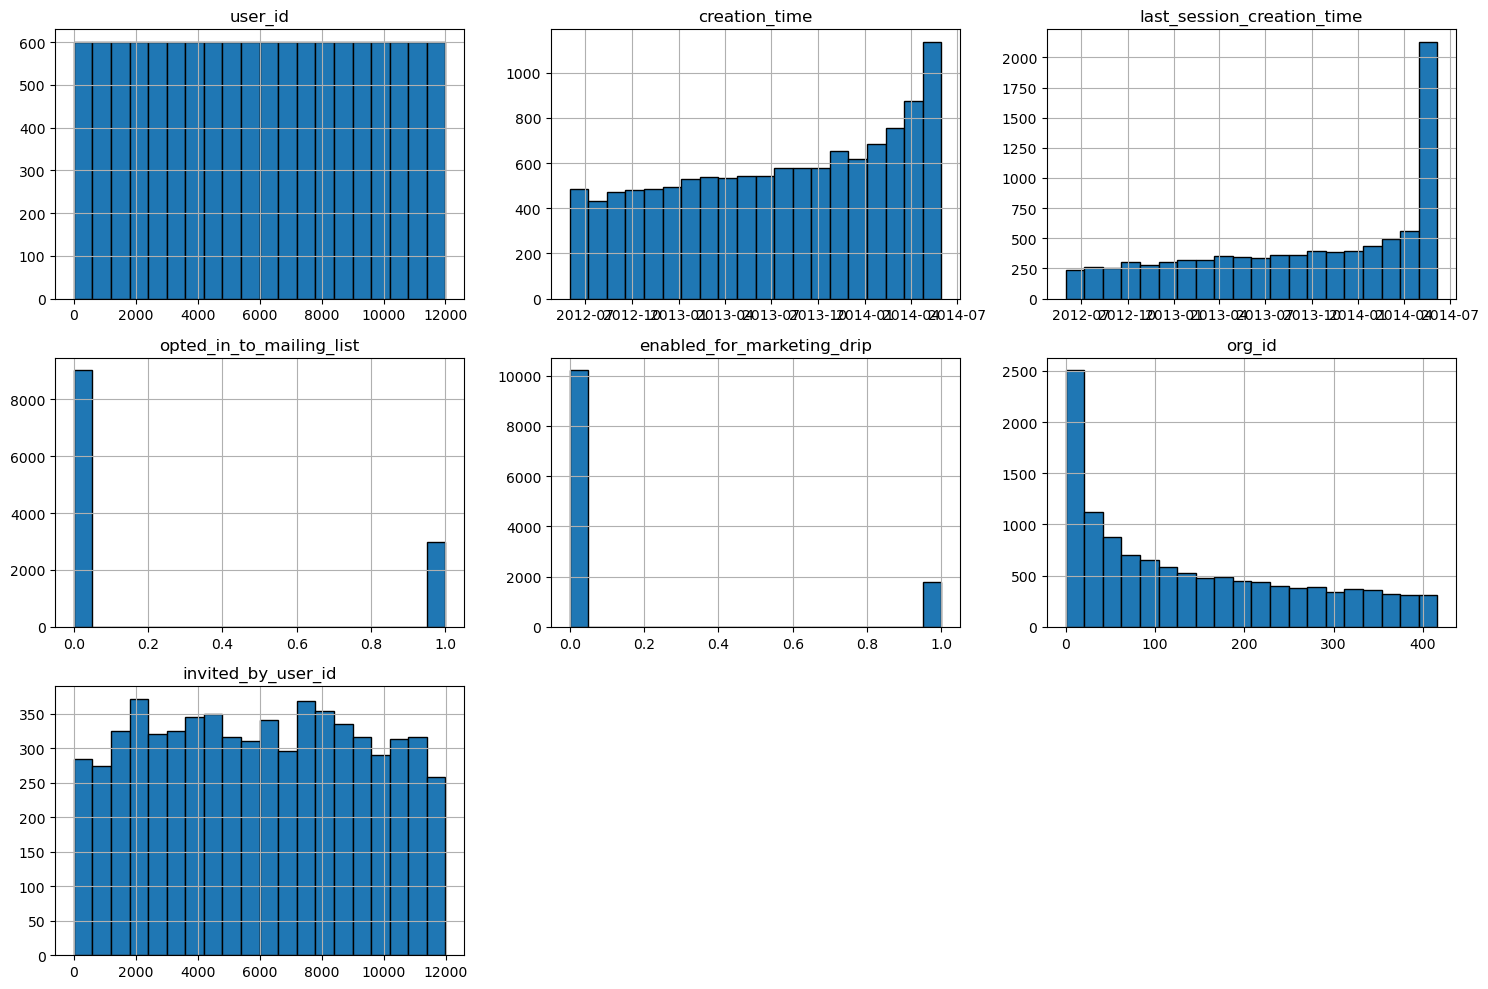

In [10]:
# Plot histograms for all numerical features in df2 (3 charts per row)
df_u.hist(figsize=(15, 10), layout=(-1, 3), bins=20, edgecolor="black")

# Adjust layout so title/labels don't overlap
plt.tight_layout()
plt.show()

### EDA - Engagement

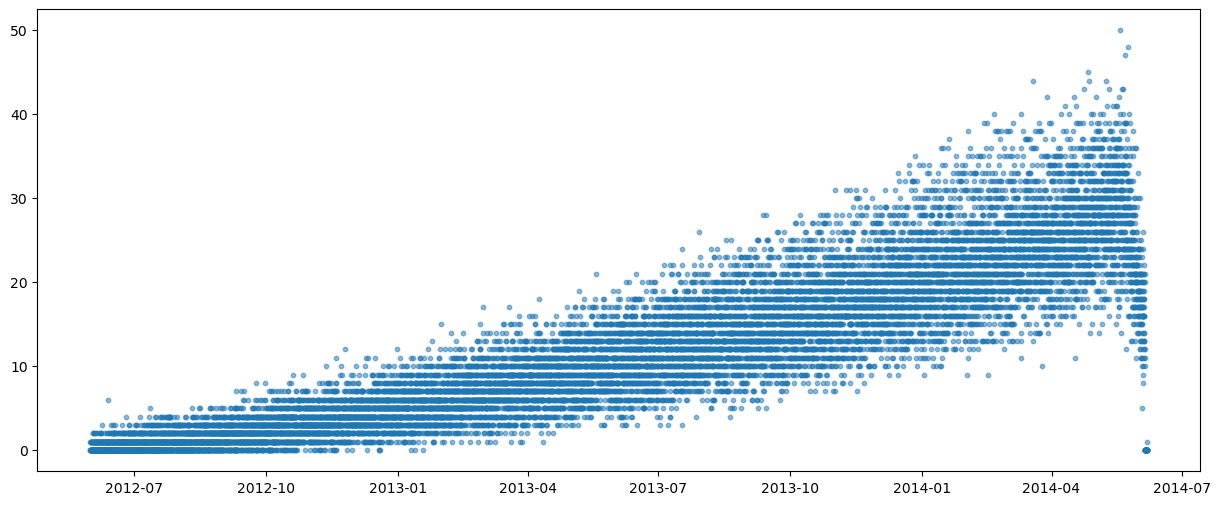

In [11]:
#Scatter plot of 60 min sampled logins
df_indexed = df_e.set_index('time_stamp')
df_indexed['count'] = 1
df_60min = df_indexed.resample('60min').sum()

plt.figure(figsize=(15, 6))
plt.scatter(df_60min.index, df_60min['count'], alpha=0.5, s=10)
plt.show()

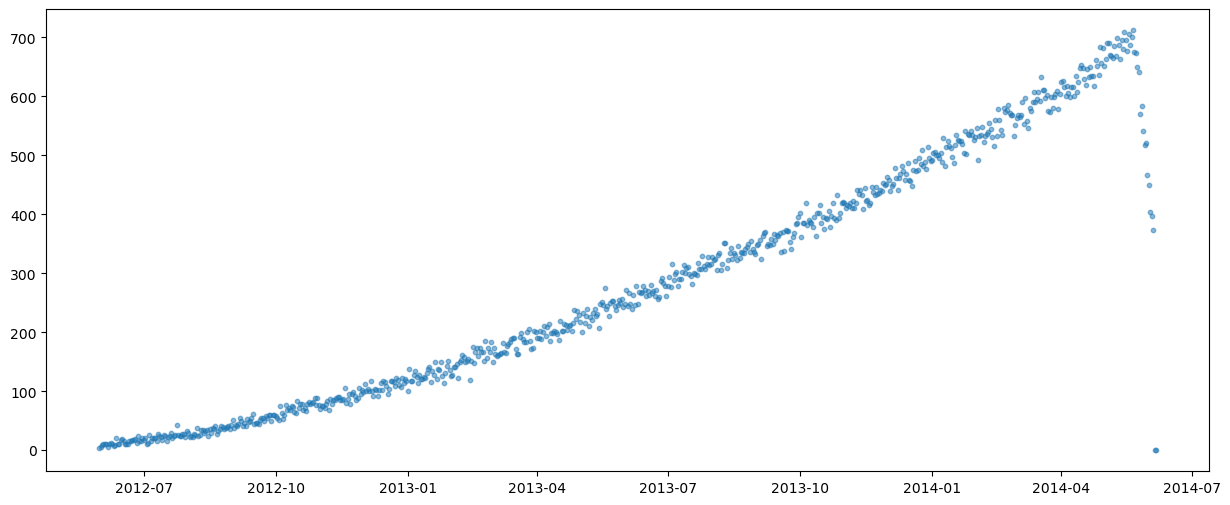

In [12]:
#Scatter plot of 1 day sampled logins
df_indexed = df_e.set_index('time_stamp')
df_indexed['count'] = 1
df_1D = df_indexed.resample('1D').sum()

plt.figure(figsize=(15, 6))
plt.scatter(df_1D.index, df_1D['count'], alpha=0.5, s=10)
plt.show()

### Adopted Users

In [13]:
# Sort and drop multiple logins on the same day for the same user
df_sorted = (
    df_e.assign(date=df_e['time_stamp'].dt.date)
    .drop_duplicates(subset=['user_id', 'date'])
    .sort_values(['user_id', 'time_stamp'])
)

# Calculate the difference between current login and 2 logins prior (3rd login in window)
df_sorted['time_diff'] = df_sorted.groupby('user_id')['time_stamp'].diff(2)

# Filter users who have at least one 3-login window within 7 days (<= 7 days)
adopted_users = df_sorted[
    df_sorted['time_diff'] <= pd.Timedelta(days=7)
]['user_id'].unique()

# Create df_a with a binary target column
df_a = pd.DataFrame({'user_id': df_e['user_id'].unique()})
df_a['adopted_user'] = df_a['user_id'].isin(adopted_users).astype(int)

df_a.head()

,user_id,adopted_user
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [14]:
# Absolute count of adopted vs. non-adopted users
counts = df_a['adopted_user'].value_counts()

# Percentage breakdown
percentages = df_a['adopted_user'].value_counts(normalize=True) * 100

# Combine into a clean summary DataFrame
adoption_summary = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(2)
})

# Rename index for clarity
adoption_summary.index = ['Non-Adopted (0)', 'Adopted (1)']
print(adoption_summary)

                 Count  Percentage (%)
Non-Adopted (0)   7167           81.23
Adopted (1)       1656           18.77


In [15]:
# join to have the target variable in df_u
df_u = pd.merge(df_u, df_a[['user_id', 'adopted_user']], on='user_id', how='left')

# fill missing values with 0 if any users in df_u had no login activity
df_u['adopted_user'] = df_u['adopted_user'].fillna(0).astype(int)

df_u.head()

,user_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted_user
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,10803.0,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,2014-03-31 03:45:04,0,0,1,316.0,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,2013-03-19 23:14:52,0,0,94,1525.0,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,5151.0,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,5240.0,0


# Feature generation and cleanup before creating model

### logins in first 14 days

In [16]:
# merge creation_time into the engagement dataframe
df_logins = df_e.merge(df_u[['user_id', 'creation_time']], on='user_id', how='inner')

# ensure both timestamp columns are in datetime format
df_logins['time_stamp'] = pd.to_datetime(df_logins['time_stamp'])
df_logins['creation_time'] = pd.to_datetime(df_logins['creation_time'])

# filter for logins within 14 days (336 hours) of account creation
is_within_14_days = (df_logins['time_stamp'] >= df_logins['creation_time']) & \
                    (df_logins['time_stamp'] <= df_logins['creation_time'] + pd.Timedelta(days=14))

logins_14d = df_logins[is_within_14_days].groupby('user_id').size().rename('total_logins_first_14_days')

# map back to df_u and fill 0 for users with no logins in their first 14 days
df_u['total_logins_first_14_days'] = df_u['user_id'].map(logins_14d).fillna(0).astype(int)

df_u[['user_id', 'creation_time', 'total_logins_first_14_days']].head()

,user_id,creation_time,total_logins_first_14_days
0,1,2014-04-22 03:53:30,1
1,2,2013-11-15 03:45:04,2
2,3,2013-03-19 23:14:52,1
3,4,2013-05-21 08:09:28,1
4,5,2013-01-17 10:14:20,1


### org_id

In [17]:
# Calculate the number of users in each org_id
org_counts = df_u['org_id'].map(df_u['org_id'].value_counts())
print(org_counts.describe(percentiles=[0.25, 0.50, 0.75]))

count    12000.000000
mean        55.108500
std         64.023959
min          2.000000
25%         21.000000
50%         29.000000
75%         55.000000
max        319.000000
Name: org_id, dtype: float64


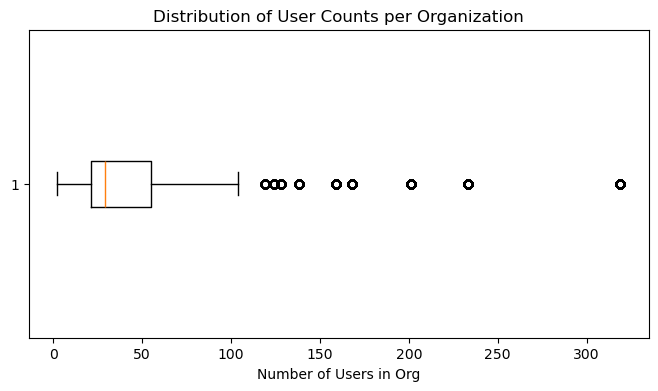

In [18]:
plt.figure(figsize=(8, 4))
plt.boxplot(org_counts, vert=False)
plt.title('Distribution of User Counts per Organization')
plt.xlabel('Number of Users in Org')
plt.show()

In [19]:
# Mark 1 if user count > 54
df_u['is_large_org'] = (org_counts > 54).astype(int)
df_u[df_u['is_large_org']==1].head()

,user_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted_user,total_logins_first_14_days,is_large_org
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,10803.0,0,1,1
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,2014-03-31 03:45:04,0,0,1,316.0,1,2,1
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,5151.0,0,1,1
13,14,2012-10-11 16:14:33,Rivera Bret,BretKRivera@gmail.com,SIGNUP,2012-10-12 16:14:33,0,0,0,NaN,0,1,1
17,18,2013-08-24 00:26:46,Gregersen Celina,CelinaAGregersen@jourrapide.com,GUEST_INVITE,NaT,0,0,2,3153.0,0,0,1


### Email

In [20]:
# extract email domain provider
df_u['email_domain'] = df_u['email'].str.split('@').str[1]

print(df_u['email_domain'].value_counts())

email_domain
gmail.com         3562
yahoo.com         2447
jourrapide.com    1259
cuvox.de          1202
gustr.com         1179
                  ... 
lrabg.com            1
mrytw.com            1
ugtav.com            1
hqhll.com            1
iuxiw.com            1
Name: count, Length: 1184, dtype: int64


In [21]:
email_domain_count = df_u['email_domain'].map(df_u['email_domain'].value_counts())
df_u['is_large_email_domain'] = (email_domain_count > 1000).astype(int)
df_u[df_u['is_large_email_domain']==1].head()

,user_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted_user,total_logins_first_14_days,is_large_org,email_domain,is_large_email_domain
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,10803.0,0,1,1,yahoo.com,1
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,2014-03-31 03:45:04,0,0,1,316.0,1,2,1,gustr.com,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,2013-03-19 23:14:52,0,0,94,1525.0,0,1,0,gustr.com,1
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,5151.0,0,1,1,yahoo.com,1
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,5240.0,0,1,0,yahoo.com,1


In [22]:
# account age
df_u['account_age_days'] = (df_u['last_session_creation_time'] - df_u['creation_time']).dt.days

#  missing last_session_creation_time means age is 0 (no login)
df_u['account_age_days'] = df_u['account_age_days'].fillna(0)

# create binary indicator for whether user was invited
df_u['is_invited'] = df_u['invited_by_user_id'].notna().astype(int)

# extract email domain provider
df_u['email_domain'] = df_u['email'].str.split('@').str[1]

# one-hot encode creation_source categorical variable
df_u = pd.get_dummies(df_u, columns=['creation_source'], drop_first=True)

# drop uninformative and raw text columns
features_to_drop = ['user_id', 'name', 'email', 'email_domain', 'creation_time', 
                    'last_session_creation_time', 'invited_by_user_id', 'org_id'
                   ]

df_model = df_u.drop(columns=[col for col in features_to_drop if col in df_u.columns])

df_model.head()

,opted_in_to_mailing_list,enabled_for_marketing_drip,adopted_user,total_logins_first_14_days,is_large_org,is_large_email_domain,account_age_days,is_invited,creation_source_ORG_INVITE,creation_source_PERSONAL_PROJECTS,creation_source_SIGNUP,creation_source_SIGNUP_GOOGLE_AUTH
0,1,0,0,1,1,1,0.0,1,False,False,False,False
1,0,0,1,2,1,1,136.0,1,True,False,False,False
2,0,0,0,1,0,1,0.0,1,True,False,False,False
3,0,0,0,1,1,1,1.0,1,False,False,False,False
4,0,0,0,1,0,1,5.0,1,False,False,False,False


# Predicition Model

In [23]:
from sklearn.model_selection import train_test_split
X = df_model.drop(columns=['adopted_user'])
y = df_model['adopted_user']

In [24]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2069
           1       0.90      0.91      0.90       331

    accuracy                           0.97      2400
   macro avg       0.94      0.95      0.94      2400
weighted avg       0.97      0.97      0.97      2400

ROC-AUC Score: 0.9935


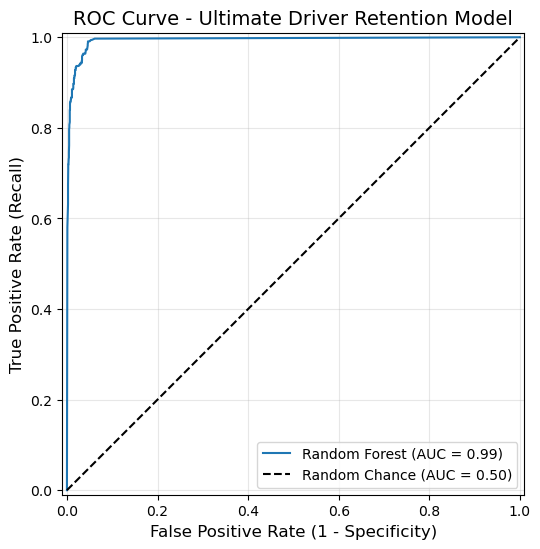

In [26]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot ROC curve using model predictions on the test set
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')

# Add baseline reference line (random chance = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')

plt.title('ROC Curve - Ultimate Driver Retention Model', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

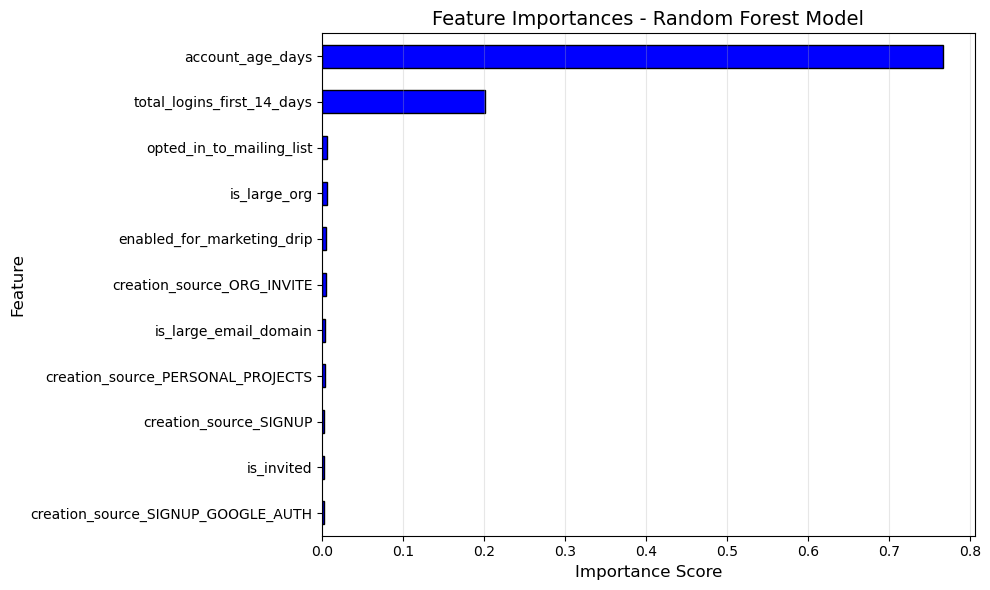

In [27]:
# Extract feature importances and pair them with column names
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='blue', edgecolor='black')

plt.title('Feature Importances - Random Forest Model', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Based on the above there is leakage between the variable account_age_days and the target variable. They are heavily correlated and thus this model is not informative. This stems from our definition of "adopted". It is highly likely that a user is "adopted" if they have had their account for a long time since there are so many changes for them to log in 3 times during a 7 day period. 

### I will remove this variable and run the prediciton model again

In [28]:
df_model = df_model.drop(columns=['account_age_days'])

In [29]:
from sklearn.model_selection import train_test_split
X = df_model.drop(columns=['adopted_user'])
y = df_model['adopted_user']

In [30]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [31]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2069
           1       0.56      0.65      0.60       331

    accuracy                           0.88      2400
   macro avg       0.75      0.78      0.76      2400
weighted avg       0.89      0.88      0.88      2400

ROC-AUC Score: 0.8545


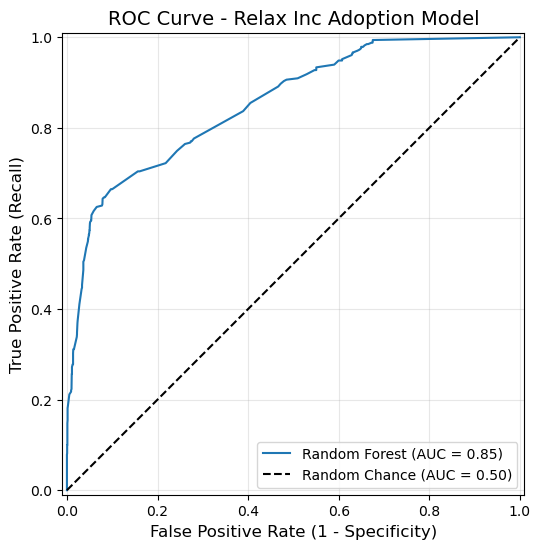

In [32]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot ROC curve using model predictions on the test set
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')

# Add baseline reference line (random chance = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')

plt.title('ROC Curve - Relax Inc Adoption Model', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

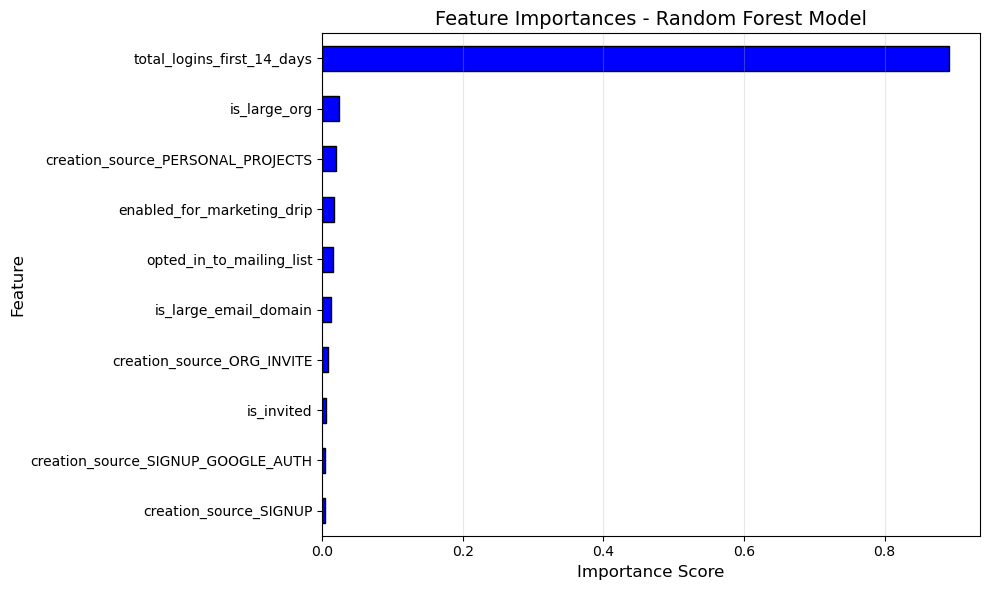

In [33]:
# Extract feature importances and pair them with column names
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='blue', edgecolor='black')

plt.title('Feature Importances - Random Forest Model', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
df_u.groupby('is_large_org')['adopted_user'].agg(['count', 'mean'])

,count,mean
is_large_org,,
0,8962,0.153091
1,3038,0.093483


# Summary

I loaded the two data sets and performed initial clean up and EDA on them. Login data spans from around July 2012 to July 2014 and there is a steady increase in logins with a sharp drop at the end. This is likely due to incomplete data for the last weeks. 

1,656 out of 8,823 users were "adopted" 

I chose a Random Forest model becuase it handles mixed data types well and captures non-linear relationships well.

My first attempt at the prediction model did not lead to informative results beause of leakage with the account_age_days variable. I reran again and got more useful result with ROC-AUC Score: 85%. This means it has an 85% probability of correctly ranking an adopted user above a non-adopted user.

total_logins_first_14_days was the strongest predictor by far. This intutively makes sense because if users are hooked from the momemnt they create an account, they are likely to be adopted.

is_large_org was the second strongest predictor. This indicates that users belonging to larger organizations (>500 members) are actually less likely to become adopted users compared to those in smaller organizations (9.3% vs 15.3% adoption rate).

These top 2 predictive variables were derived using inuition after examining the datasets. for next steps, I would recommend exploring other derived fields and testing their predictive power.

Some other potentially useful fields would be:
<br> -Work-related account (1/0)
<br> -Org classification (hospitality, tech, healthcare, etc.)
<br> -Demographics information (gender, age, zip code, etc.)